In [4]:
import os
import time
import datetime
import pandas as pd
import numpy as np
import sys
from metric import eval_metrics
# ignore all warnings
import warnings
warnings.filterwarnings('ignore')


real_df = pd.read_csv("/Users/vsekar/AINTEC_Tutorial/generative-trace-tutorials/data/small-scale/caida/raw.csv").head(1000)
gen_df = pd.read_csv("generated_pcap_ctgan.csv")

print(f"\nReal data shape: {real_df.shape}")
print(f"Generated data shape: {gen_df.shape}")
print(f"Real data columns: {list(real_df.columns)}")
print(f"Generated data columns: {list(gen_df.columns)}")
print("\nRunning comprehensive fidelity evaluation...")
print("This may take a few minutes depending on data size...\n")


Real data shape: (1000, 15)
Generated data shape: (1000, 16)
Real data columns: ['srcip', 'dstip', 'srcport', 'dstport', 'proto', 'time', 'pkt_len', 'version', 'ihl', 'tos', 'id', 'flag', 'off', 'ttl', 'chksum']
Generated data columns: ['Unnamed: 0', 'srcip', 'dstip', 'srcport', 'dstport', 'proto', 'time', 'pkt_len', 'version', 'ihl', 'tos', 'id', 'flag', 'off', 'ttl', 'chksum']

Running comprehensive fidelity evaluation...
This may take a few minutes depending on data size...



Evaluating Flow Stateful Metrics: 100%|█████| 42/42 [00:00<00:00, 85.43metric/s]



Average Scores by Category:
  Packet-Level:            0.2226
  Flow-Level Stateless:    0.6226
  Flow-Level Stateful:     0.6932

Generating visualizations...



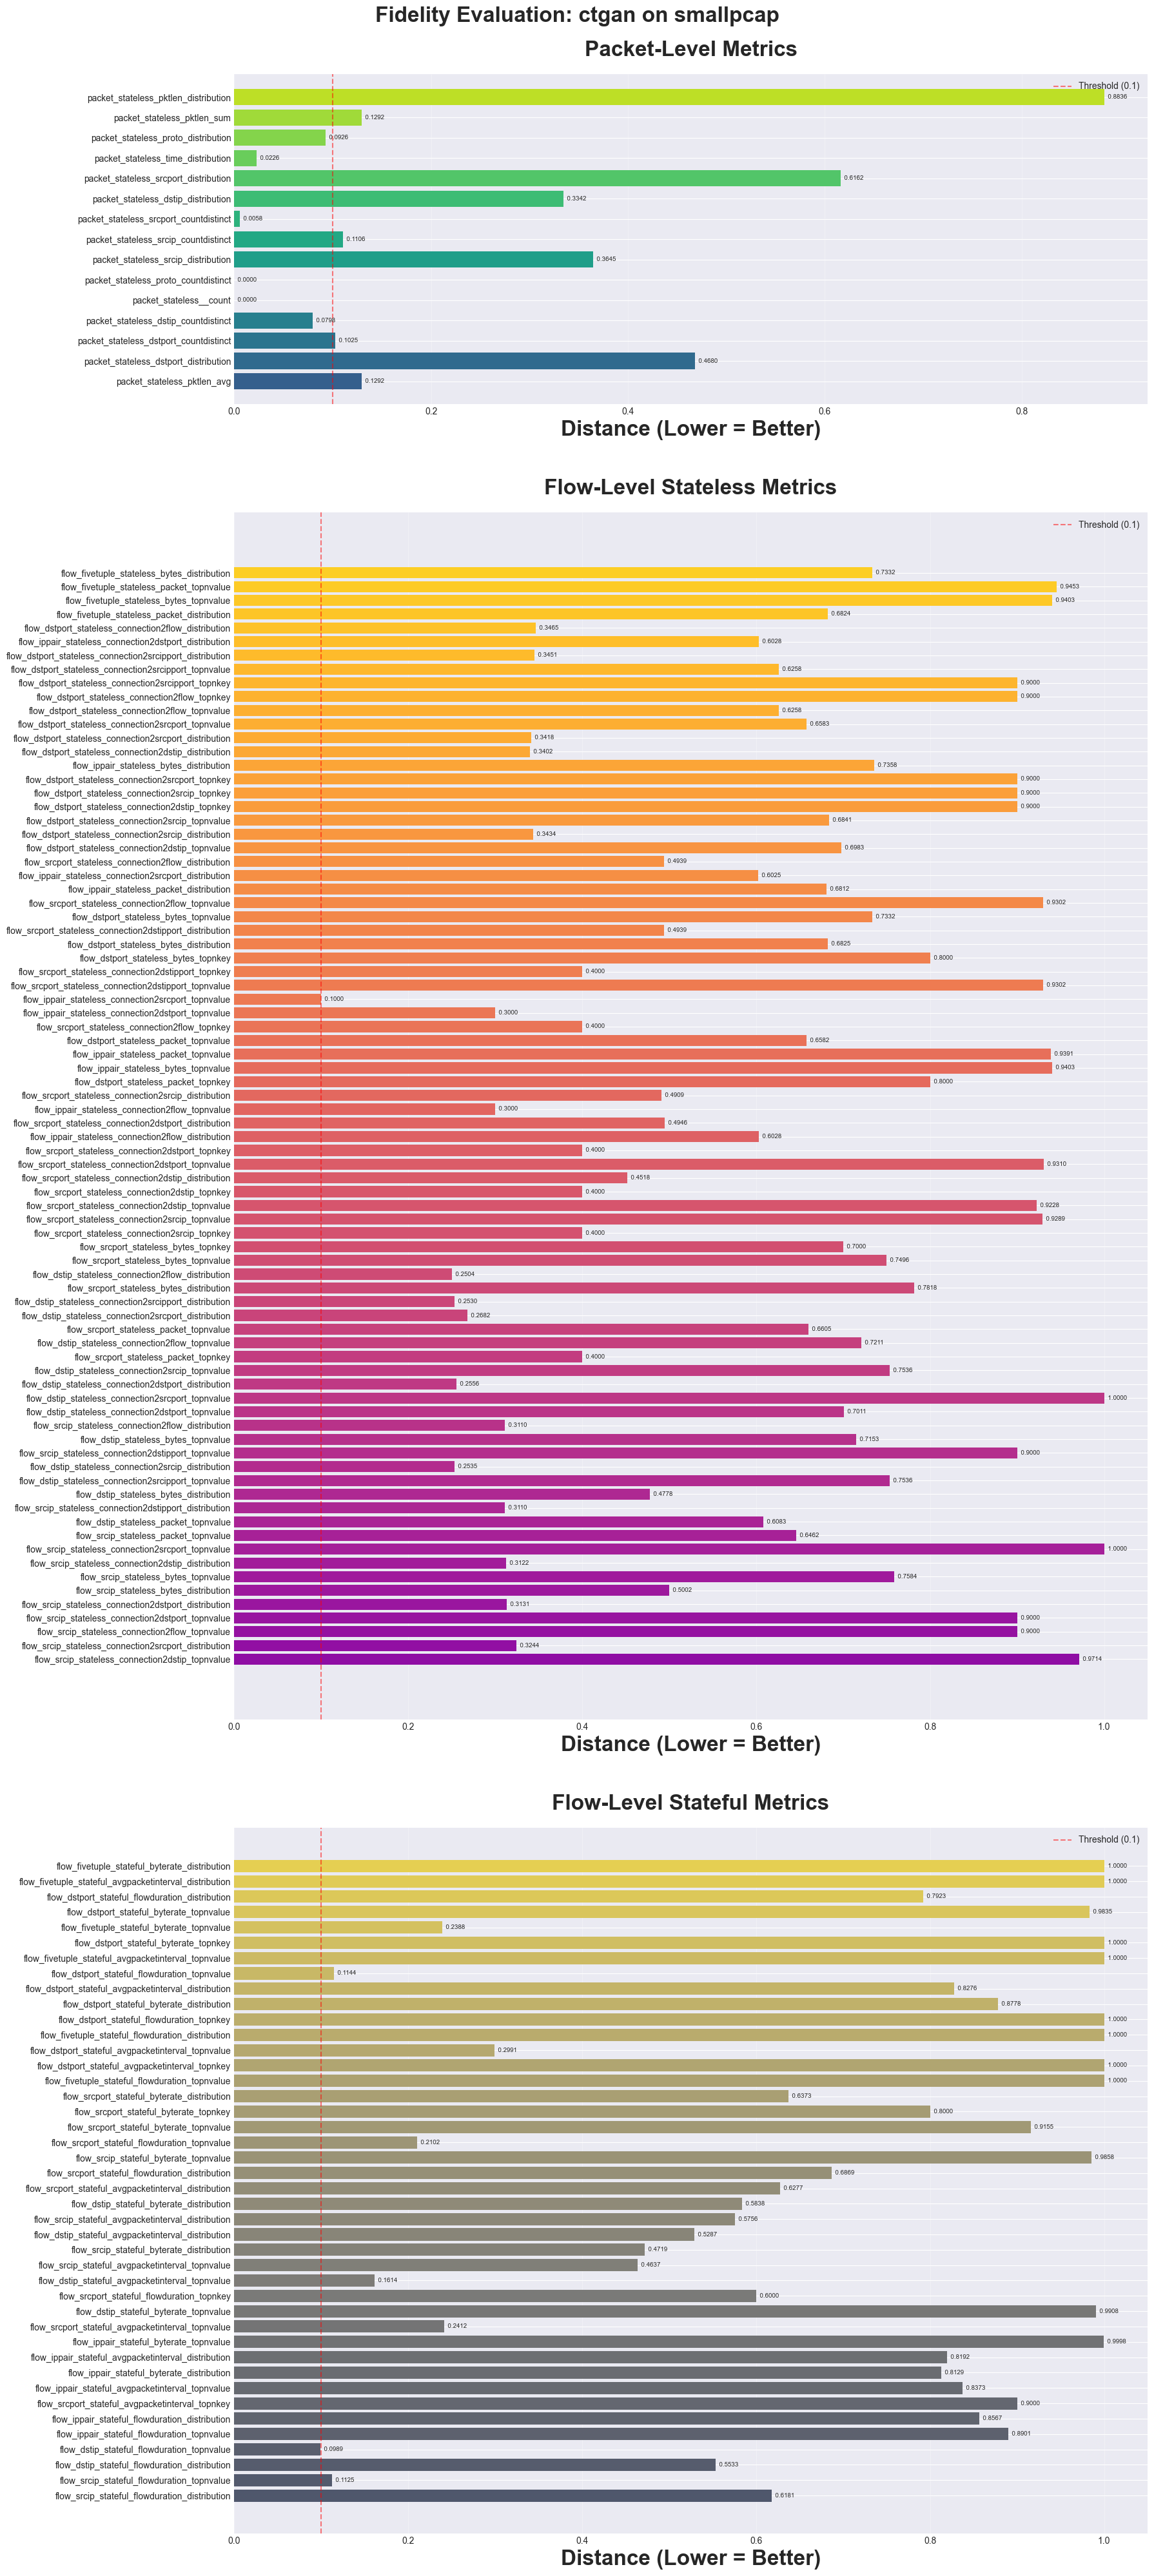


SUMMARY STATISTICS
Total metrics evaluated: 137
Average distance: 0.6004
Median distance: 0.6373
Min distance: 0.0000
Max distance: 1.0000
Metrics below 0.1 threshold: 7/137 (5.1%)


In [6]:


model_name= "ctgan"
dataset_name ="smallpcap"


# Run evaluation with multiple metrics
# n=10 means we look at top-10 values for various distributions
# n_threads controls parallel processing (adjust based on your CPU)
rst = eval_metrics(real_df, gen_df, n=10, n_threads=16)

import matplotlib.pyplot as plt
%matplotlib inline

# Display average scores for each category
print("\nAverage Scores by Category:")
print(f"  Packet-Level:            {rst['packet']['avg']:.4f}")
print(f"  Flow-Level Stateless:    {rst['flow_stateless']['avg']:.4f}")
print(f"  Flow-Level Stateful:     {rst['flow_stateful']['avg']:.4f}")
print("\nGenerating visualizations...\n")

# Set up the plotting style
plt.style.use('seaborn-v0_8-darkgrid')
fig = plt.figure(figsize=(18, 40))

# ===== Plot 1: Packet-Level Metrics =====
ax1 = plt.subplot2grid((40, 1), (0, 0), rowspan=6, fig=fig)
packet_metrics = rst['packet']['score']  # Extract the 'score' dictionary
metric_names = list(packet_metrics.keys())
metric_values = list(packet_metrics.values())

# Create color map for better visualization
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(metric_names)))

bars1 = ax1.barh(metric_names, metric_values, color=colors[:len(metric_names)])
ax1.set_xlabel('Distance (Lower = Better)', fontsize=24, fontweight='bold')
ax1.set_title('Packet-Level Metrics', fontsize=24, fontweight='bold', pad=20)
ax1.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (name, value) in enumerate(zip(metric_names, metric_values)):
    ax1.text(value, i, f'  {value:.4f}', va='center', fontsize=7)

# Add a reference line at a good threshold (e.g., 0.1)
ax1.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Threshold (0.1)')
ax1.legend(loc='upper right')

# ===== Plot 2: Flow-Level Stateless Metrics =====
ax2 = plt.subplot2grid((40, 1), (7, 0), rowspan=20, fig=fig)
stateless_metrics = rst['flow_stateless']['score']  # Extract the 'score' dictionary
metric_names_sl = list(stateless_metrics.keys())
metric_values_sl = list(stateless_metrics.values())

colors_sl = plt.cm.plasma(np.linspace(0.3, 0.9, len(metric_names_sl)))
bars2 = ax2.barh(metric_names_sl, metric_values_sl, color=colors_sl)
ax2.set_xlabel('Distance (Lower = Better)', fontsize=24, fontweight='bold')
ax2.set_title('Flow-Level Stateless Metrics', fontsize=24, fontweight='bold', pad=20)
ax2.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (name, value) in enumerate(zip(metric_names_sl, metric_values_sl)):
    ax2.text(value, i, f'  {value:.4f}', va='center', fontsize=7)

# Add reference line
ax2.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Threshold (0.1)')
ax2.legend(loc='upper right')

# ===== Plot 3: Flow-Level Stateful Metrics =====
ax3 = plt.subplot2grid((40, 1), (28, 0), rowspan=12, fig=fig)
stateful_metrics = rst['flow_stateful']['score']  # Extract the 'score' dictionary
metric_names_sf = list(stateful_metrics.keys())
metric_values_sf = list(stateful_metrics.values())

colors_sf = plt.cm.cividis(np.linspace(0.3, 0.9, len(metric_names_sf)))
bars3 = ax3.barh(metric_names_sf, metric_values_sf, color=colors_sf)
ax3.set_xlabel('Distance (Lower = Better)', fontsize=24, fontweight='bold')
ax3.set_title('Flow-Level Stateful Metrics', fontsize=24, fontweight='bold', pad=20)
ax3.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (name, value) in enumerate(zip(metric_names_sf, metric_values_sf)):
    ax3.text(value, i, f'  {value:.4f}', va='center', fontsize=7)

# Add reference line
ax3.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Threshold (0.1)')
ax3.legend(loc='upper right')

# Overall title
fig.suptitle(f'Fidelity Evaluation: {model_name} on {dataset_name}', 
             fontsize=24, fontweight='bold', y=0.998)

plt.tight_layout()
plt.show()

# Calculate and display summary statistics
all_values = metric_values + metric_values_sl + metric_values_sf
print(f"\n{'='*60}")
print(f"SUMMARY STATISTICS")
print(f"{'='*60}")
print(f"Total metrics evaluated: {len(all_values)}")
print(f"Average distance: {np.mean(all_values):.4f}")
print(f"Median distance: {np.median(all_values):.4f}")
print(f"Min distance: {np.min(all_values):.4f}")
print(f"Max distance: {np.max(all_values):.4f}")
below_threshold = sum(v < 0.1 for v in all_values)
print(f"Metrics below 0.1 threshold: {below_threshold}/{len(all_values)} ({100*below_threshold/len(all_values):.1f}%)")
print(f"{'='*60}")